# **Image Classification using CNN Exercise**

In [1]:
!pip install -q torchmetrics mlxtend


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 59.2 MB/s eta 0:00:00


In [2]:
# Check for GPU
!nvidia-smi

Thu Jul  9 12:34:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# Import torch
import torch
from torch import nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

2.11.0+cu128
Using device: cuda


## **Q1 Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?**

In [4]:
random_tensor = torch.rand(size=[1, 3, 64, 64])
print(f"Input shape: {random_tensor.shape}")

# Try different kernel sizes (keeping stride=2, padding=1 like a typical conv block)
for kernel_size in [1, 3, 5, 7]:
    conv_layer = nn.Conv2d(
        in_channels=3,
        out_channels=64,
        kernel_size=kernel_size,
        stride=2,
        padding=1,
    )
    output = conv_layer(random_tensor)
    print(f"kernel_size={kernel_size} -> output shape: {output.shape}")

# What do you notice?
# As kernel_size increases, the output spatial dimensions get smaller (e.g. 64x64 -> 32x32 with k=3,
# but even smaller with larger kernels). A larger kernel looks at a bigger patch of the image at once
# (larger receptive field), while a smaller kernel captures finer local details.

Input shape: torch.Size([1, 3, 64, 64])
kernel_size=1 -> output shape: torch.Size([1, 64, 33, 33])
kernel_size=3 -> output shape: torch.Size([1, 64, 32, 32])
kernel_size=5 -> output shape: torch.Size([1, 64, 31, 31])
kernel_size=7 -> output shape: torch.Size([1, 64, 30, 30])


## **Q2 Write transforms necessary for data augmentation for the `MNIST` dataset**

In [5]:
# Transforms for training (with data augmentation) and testing (no augmentation)
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
])

train_transform, test_transform

(Compose(
     ToTensor()
     RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
     RandomAffine(degrees=[0.0, 0.0], translate=(0.1, 0.1), scale=(0.9, 1.1))
 ),
 Compose(
     ToTensor()
 ))

## **Q3 Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets**

In [6]:
train_data = datasets.MNIST(
    root=".",
    train=True,
    download=True,
    transform=train_transform,
)

test_data = datasets.MNIST(
    root=".",
    train=False,
    download=True,
    transform=test_transform,
)

class_names = train_data.classes
len(train_data), len(test_data), class_names

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.51MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.7MB/s]


(60000,
 10000,
 ['0 - zero',
  '1 - one',
  '2 - two',
  '3 - three',
  '4 - four',
  '5 - five',
  '6 - six',
  '7 - seven',
  '8 - eight',
  '9 - nine'])

## **Q4 Visualize at least 5 different samples of the MNIST training dataset**

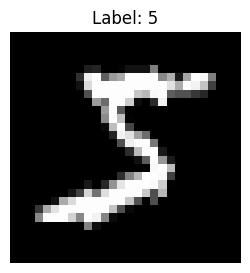

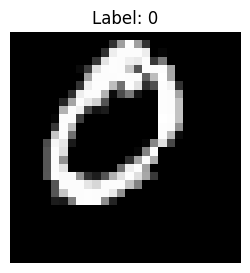

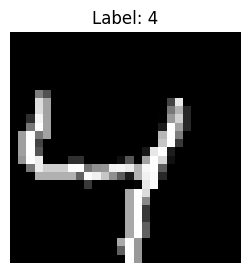

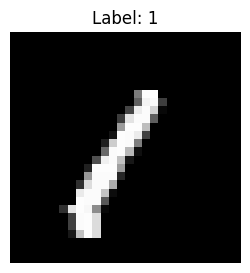

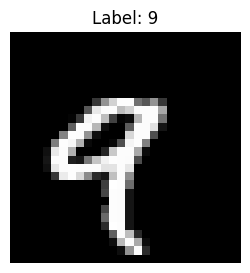

In [7]:
for i in range(5):
    img, label = train_data[i]
    plt.figure(figsize=(3, 3))
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis(False)
    plt.show()

## **Q5 Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`**

In [8]:
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=32,
    shuffle=True,
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=32,
    shuffle=False,
)

len(train_dataloader), len(test_dataloader)

(1875, 313)

## **Q6 Create a CNN model following the architecture in the [CNN Explainer](https://poloclub.github.io/cnn-explainer/).**

In [9]:
class MNIST_model(nn.Module):
    """TinyVGG-style CNN (same architecture as CNN Explainer / notebook 03)."""
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(input_shape, hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 7 * 7, out_features=output_shape),
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x

torch.manual_seed(42)
model = MNIST_model(input_shape=1, hidden_units=10, output_shape=10).to(device)
model

MNIST_model(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

## **Q7 Train the model you built in Q6 for 5 epochs**

In [10]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

epochs = 5
for epoch in tqdm(range(epochs)):
    train_loss = 0
    model.train()
    for X, y in train_dataloader:
        X, y = X.to(device), y.to(device)

        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(train_dataloader)

    test_loss_total = 0
    model.eval()
    with torch.inference_mode():
        for X_test, y_test in test_dataloader:
            X_test, y_test = X_test.to(device), y_test.to(device)
            test_pred = model(X_test)
            test_loss_total += loss_fn(test_pred, y_test).item()

    test_loss_total /= len(test_dataloader)
    print(f"Epoch: {epoch} | Train loss: {train_loss:.3f} | Test loss: {test_loss_total:.3f}")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train loss: 0.516 | Test loss: 0.072
Epoch: 1 | Train loss: 0.180 | Test loss: 0.064
Epoch: 2 | Train loss: 0.149 | Test loss: 0.058
Epoch: 3 | Train loss: 0.130 | Test loss: 0.043
Epoch: 4 | Train loss: 0.116 | Test loss: 0.048


## **Q8 Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label**

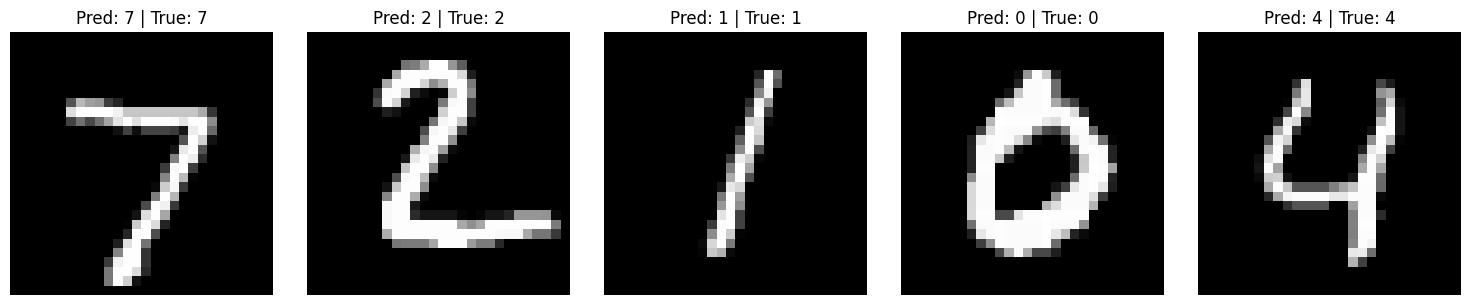

In [11]:
model.eval()
test_images, test_labels = next(iter(test_dataloader))

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
with torch.inference_mode():
    for i in range(5):
        img = test_images[i].unsqueeze(0).to(device)
        pred = torch.argmax(model(img), dim=1).item()
        true_label = test_labels[i].item()

        axes[i].imshow(test_images[i].squeeze(), cmap="gray")
        axes[i].set_title(f"Pred: {pred} | True: {true_label}")
        axes[i].axis(False)

plt.tight_layout()
plt.show()

## **Q9 Plot a confusion matrix comparing your model's predictions to the truth labels**



  0%|          | 0/313 [00:00<?, ?it/s]

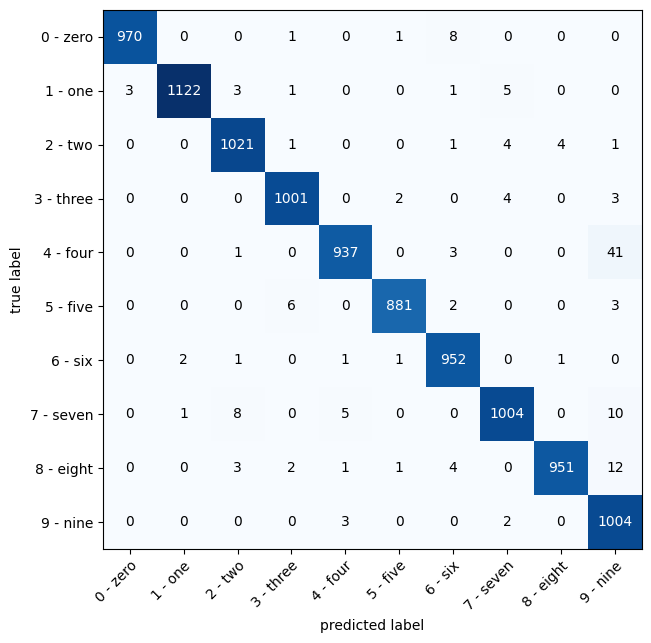

In [12]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

model.eval()
y_preds = []
with torch.inference_mode():
    for X, y in tqdm(test_dataloader):
        X = X.to(device)
        y_pred_logits = model(X)
        y_pred_labels = torch.argmax(y_pred_logits, dim=1)
        y_preds.append(y_pred_labels.cpu())

y_preds = torch.cat(y_preds)

confmat = ConfusionMatrix(task="multiclass", num_classes=len(class_names))
confmat_tensor = confmat(preds=y_preds, target=test_data.targets)

fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7),
)

## **Q10 Result Analysis**
* Plot some predictions from the test_data above where the model was wrong alongside what the label of the image should've been.

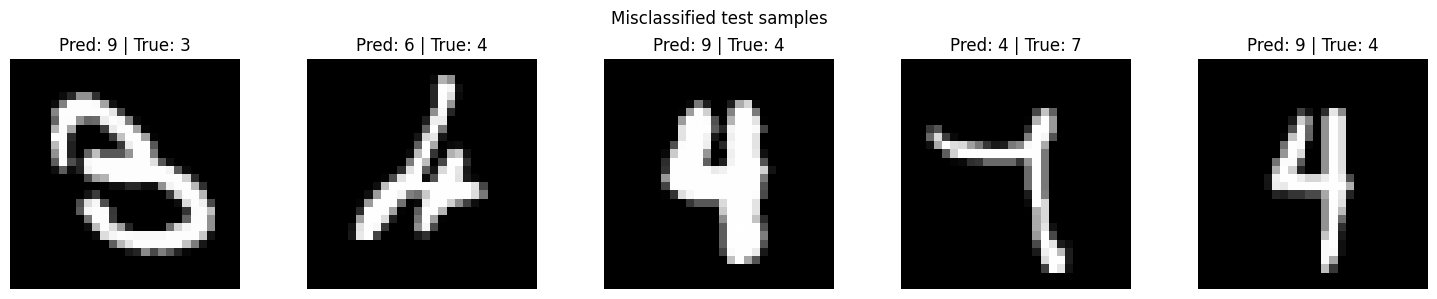

In [13]:
wrong_mask = y_preds != test_data.targets
wrong_indices = wrong_mask.nonzero().squeeze()

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for plot_i, data_idx in enumerate(wrong_indices[:5]):
    img, true_label = test_data[data_idx]
    pred_label = y_preds[data_idx].item()

    axes[plot_i].imshow(img.squeeze(), cmap="gray")
    axes[plot_i].set_title(f"Pred: {pred_label} | True: {true_label}")
    axes[plot_i].axis(False)

plt.suptitle("Misclassified test samples")
plt.tight_layout()
plt.show()

* After visualing these predictions do you think it's more of a **modelling error** or a **data error**?

> Mostly a **modelling error**. MNIST labels are generally clean and unambiguous, but a small CNN trained for only 5 epochs will still confuse visually similar digits (e.g. 4 vs 9, 7 vs 2). With more training, a deeper model, or better hyperparameters, accuracy can improve further.

* As in, could the model do better or are the labels of the data too close to each other (e.g. a "7" label is too close to "2")?

> The model **could do better** — it has not fully learned all digit patterns yet. Some errors happen because certain digits look alike (7 vs 2, 4 vs 9, 3 vs 8), but this is usually ambiguity in handwriting rather than wrong labels. So it is a mix: mostly modelling capacity/training, with a small amount of naturally similar-looking digits.